### FASE 3. Análisis Exploratorio de Datos (EDA)

**Proyecto:** Análisis Exploratorio de Datos — Campañas de Marketing Bancario

**Objetivo de esta fase:**
Comprender el comportamiento de los datos mediante estadísticas descriptivas y visualizaciones, identificando patrones, relaciones entre variables y, especialmente, qué factores se asocian a que un cliente suscriba el depósito a plazo (variable `y`).

**Punto de partida:** `02_datos_limpios.csv` (42.752 filas × 30 columnas), resultado de la Fase 2.

**Flujo que seguiremos:**
1. Recordatorio Pre-EDA.
2. Identificar variables categóricas y numéricas.
3. Análisis univariante (categóricas y numéricas).
4. Análisis bivariante — relación con la variable objetivo `y`.
5. Relación entre variables numéricas y correlaciones globales.
6. Evolución temporal.
7. Preguntas de negocio.
8. Conclusiones de la fase.


#### 0️⃣ Carga del dataset limpio

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
sns.set_context("notebook")

df = pd.read_csv(
    "02_datos_limpios.csv",
    parse_dates=["date", "Dt_Customer"]
)

df.head(3).T


,0,1,2
age,38.0,57.0,37.0
job,housemaid,services,services
marital,married,married,married
education,basic.4y,high.school,high.school
default,no,desconocido,no
housing,no,no,si
loan,no,no,no
contact,telephone,telephone,telephone
duration,261,149,226
campaign,1,1,1


#### 1️⃣ Recordatorio Pre-EDA

Antes de visualizar, repasamos brevemente la estructura del dataset ya limpio (esto ya se comprobó en detalle en la Fase 2).


In [3]:
print("Tamaño del df:", df.shape)
df.info()


Tamaño del df: (42752, 30)
<class 'pandas.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   age                     42752 non-null  float64       
 1   job                     42752 non-null  str           
 2   marital                 42752 non-null  str           
 3   education               42752 non-null  str           
 4   default                 42752 non-null  str           
 5   housing                 42752 non-null  str           
 6   loan                    42752 non-null  str           
 7   contact                 42752 non-null  str           
 8   duration                42752 non-null  int64         
 9   campaign                42752 non-null  int64         
 10  pdays                   42752 non-null  int64         
 11  previous                42752 non-null  int64         
 12  poutcome                42752 

In [4]:
# Confirmamos que no quedan nulos tras la Fase 2
df.isnull().sum().sum()


np.int64(0)

#### 2️⃣ Identificar variables categóricas y numéricas

In [5]:
columnas_categoricas = df.select_dtypes(include=["object", "string","category"]).columns.tolist()
columnas_categoricas = [c for c in columnas_categoricas if c != "id_cliente"]  # id_cliente no se analiza

columnas_numericas = df.select_dtypes(include=["number"]).columns.tolist()

print("Categóricas:", columnas_categoricas)
print()
print("Numéricas:", columnas_numericas)


Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y', 'contactado_previamente']

Numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'latitude', 'longitude', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth', 'año_alta_cliente']


**Nota:** `y` → indica si el cliente ha suscrito el depósito a plazo (`yes` / `no`).<br> Gran parte del análisis bivariante de esta fase se centrará en relacionar el resto de variables con `y`.


#### 3️⃣ Análisis descriptivo general

In [6]:
# Analizamos columnas_numerica
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,42752.0,39.745018,9.822489,17.000,33.000,38.000000,46.000,98.000
duration,42752.0,257.766186,258.778698,0.000,102.000,179.000000,319.000,4918.000
campaign,42752.0,2.566383,2.770606,1.000,1.000,2.000000,3.000,56.000
pdays,42752.0,962.373877,187.154560,0.000,999.000,999.000000,999.000,999.000
previous,42752.0,0.174237,0.497828,0.000,0.000,0.000000,0.000,7.000
emp.var.rate,42752.0,0.077330,1.573703,-3.400,-1.800,1.100000,1.400,1.400
cons.price.idx,42752.0,93.574316,0.576529,92.201,93.075,93.574219,93.994,94.767
cons.conf.idx,42752.0,-40.510100,4.637412,-50.800,-42.700,-41.800000,-36.400,-26.900
euribor3m,42752.0,3.883822,1.620777,0.634,1.479,4.857000,4.959,5.045
nr.employed,42752.0,5166.866537,72.392792,4963.600,5099.100,5191.000000,5228.100,5228.100


In [7]:
# Analizamos columnas_categoticas
df[columnas_categoricas].describe().T


,count,unique,top,freq
job,42752,12,admin.,10802
marital,42752,4,married,25840
education,42752,8,university.degree,12642
default,42752,3,no,33810
housing,42752,3,si,22367
loan,42752,3,no,35244
contact,42752,2,cellular,27232
poutcome,42752,3,nonexistent,36883
y,42752,2,no,37941
contactado_previamente,42752,2,no,41175


Distribución de la variable "y"

In [14]:
# Calculamos el valor total de cada variable
df["y"].value_counts(normalize=False)

y
no     37941
yes     4811
Name: count, dtype: int64

In [15]:
# Calculamos el porcentaje 
df["y"].value_counts(normalize=True).round(4) * 100

y
no     88.75
yes    11.25
Name: proportion, dtype: float64

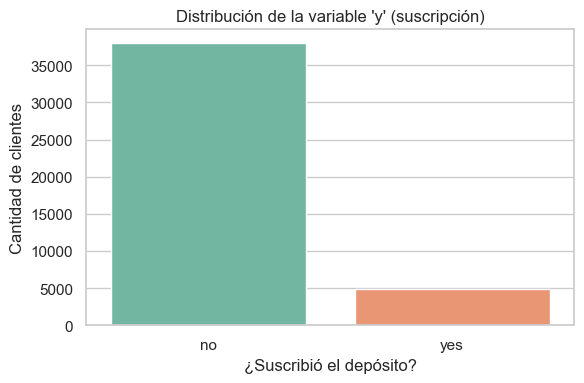

In [9]:
# Graficamos "y"
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="y", hue="y", palette="Set2", legend=False)
plt.title("Distribución de la variable 'y' (suscripción)")
plt.xlabel("¿Suscribió el depósito?")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()


**Interpretación:** el dataset está claramente **desbalanceado**: solo el **11,25 %** de los clientes contactados terminó suscribiendo el depósito, frente a un **88,75 %** que no lo hizo. <br> Es importante tener esto en cuenta en el resto del análisis: cualquier grupo con una tasa de suscripción por encima del 11-12 % puede considerarse "por encima de la media".


#### 4️⃣ Análisis univariante — Variables categóricas

Usamos `countplot()` para conocer la frecuencia de cada categoría.


In [23]:
# Recordamos las columnas_categoricas menos id.
print(columnas_categoricas)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y', 'contactado_previamente']


4.1. Profesión (`job`)

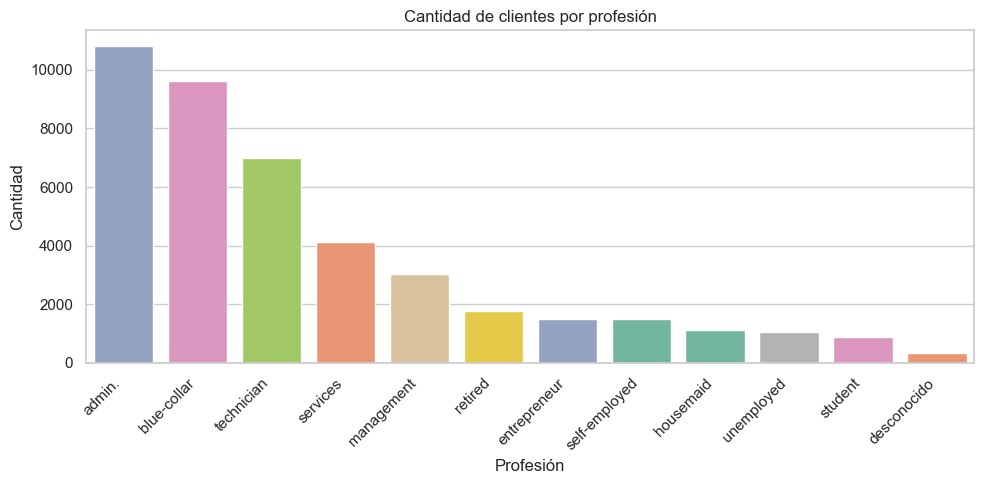

In [16]:
plt.figure(figsize=(10,5))
orden = df["job"].value_counts().index # ordenamos de mayor a menor
sns.countplot(data=df, x="job", hue="job", order=orden, palette="Set2", legend=False)
plt.title("Cantidad de clientes por profesión")
plt.xlabel("Profesión")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretación:** las profesiones más frecuentes en la base de clientes contactados son `admin.`, `blue-collar` y `technician`. <br> Esto es relevante porque, como veremos en el análisis bivariante, la tasa de conversión varía bastante según la profesión.


4.2. Estado civil (`marital`), Nivel educativo (`education`)

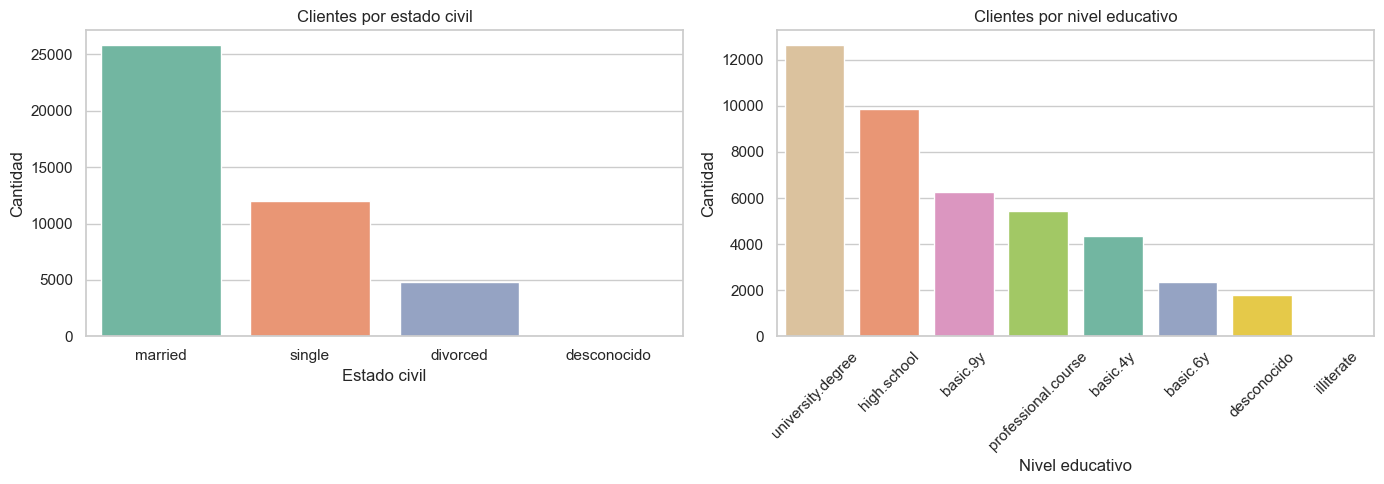

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(data=df, x="marital", hue="marital", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Clientes por estado civil")
axes[0].set_xlabel("Estado civil")
axes[0].set_ylabel("Cantidad")

orden_edu = df["education"].value_counts().index
sns.countplot(data=df, x="education", hue="education", order=orden_edu, palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Clientes por nivel educativo")
axes[1].set_xlabel("Nivel educativo")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Interpretación:** 
- En la Gráfica Clientes por estado civil observamos que los clientes `married`(casados) duplican al resto de los estados civiles.
- En la Gráfica Clientes por nivel educativo destacan los clientes `university.degree`(con titulo universitario) y `high.school`(con titulo secundario) destacan sobre el resto de clientes.


4.3. Método de contacto (`contact`) y resultado de campaña anterior (`poutcome`)

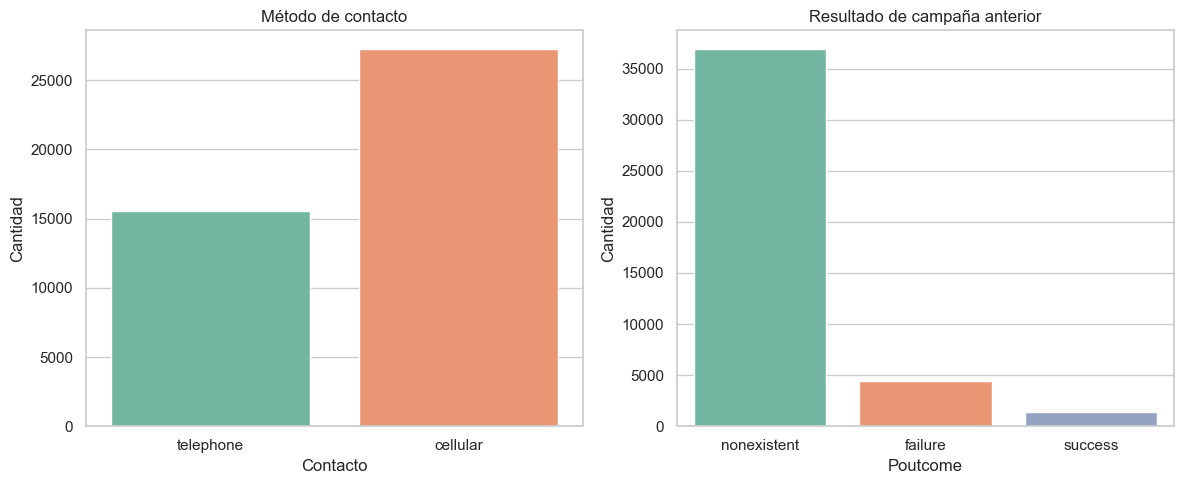

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(data=df, x="contact", hue="contact", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Método de contacto")
axes[0].set_xlabel("Contacto")
axes[0].set_ylabel("Cantidad")

sns.countplot(data=df, x="poutcome", hue="poutcome", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Resultado de campaña anterior")
axes[1].set_xlabel("Poutcome")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()


**Interpretación:** <br> 
- La mayoría de los contactos se realizan por `cellular`(Movil). <br> 
- En cuanto a `poutcome`, la mayoría de los clientes (`nonexistent`) no tenían una campaña anterior registrada, <br> lo que es coherente con `contactado_previamente = "no"` que veremos a continuación.


4.4. Préstamos y morosidad (`default`, `housing`, `loan`) y contacto previo

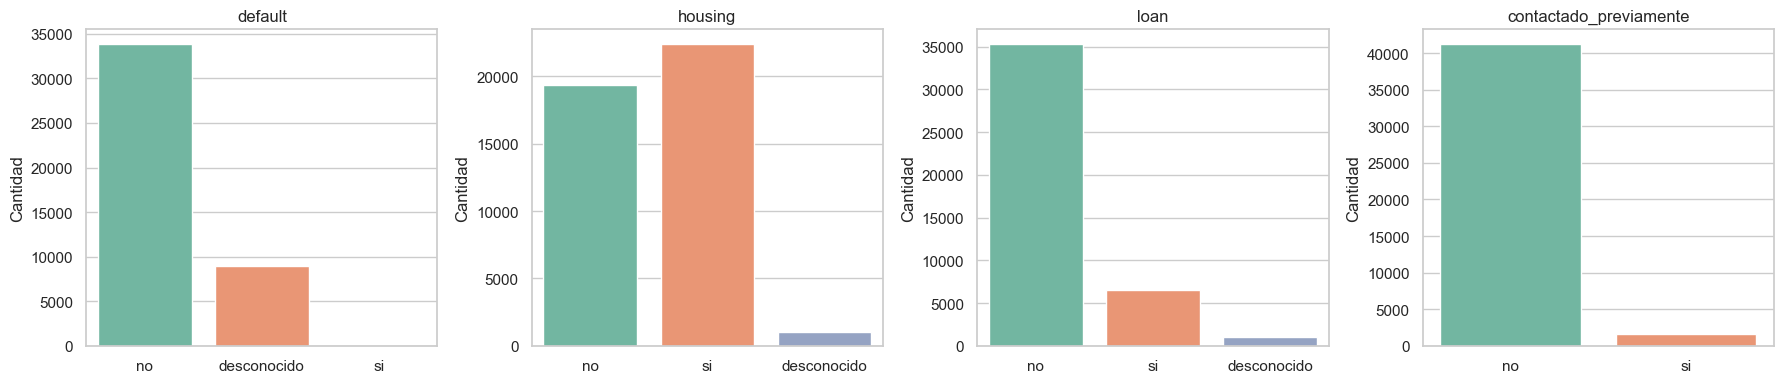

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

for ax, col in zip(axes, ["default", "housing", "loan", "contactado_previamente"]):
    sns.countplot(data=df, x=col, hue=col, palette="Set2", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()


In [26]:
# Realizamos un analisis de las Gráfica en porcentajes 
for col in ["default", "housing", "loan", "contactado_previamente"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print()


--- default ---
default
no             79.1
desconocido    20.9
si              0.0
Name: proportion, dtype: float64

--- housing ---
housing
si             52.3
no             45.3
desconocido     2.4
Name: proportion, dtype: float64

--- loan ---
loan
no             82.4
si             15.2
desconocido     2.4
Name: proportion, dtype: float64

--- contactado_previamente ---
contactado_previamente
no    96.3
si     3.7
Name: proportion, dtype: float64



**Interpretación:**
- `default` (historial de impago): la inmensa mayoría de clientes no tiene incumplimientos de pagos declarados; destaca el volumen de la categoría `desconocido` (~21 %), reflejo de los nulos imputados en la Fase 2.
- `housing`(con prestamo hipotecario) y `loan` (otro tipo de prestamo): aproximadamente la mitad de los clientes tiene préstamo hipotecario, y una minoría tiene otro tipo de préstamo personal.
- `contactado_previamente`: el **96,3 %** de los clientes nunca había sido contactado antes de esta campaña (`pdays = 999`), lo que confirma que la mayor parte del esfuerzo comercial se dirige a clientes nuevos en campañas.


#### 5️⃣ Análisis univariante — Variables numéricas

Usamos `histplot(kde=True)` para ver la forma de la distribución de cada variable numérica.


In [28]:
# Recordamos las columnas_numericas
print(columnas_numericas)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'latitude', 'longitude', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth', 'año_alta_cliente']


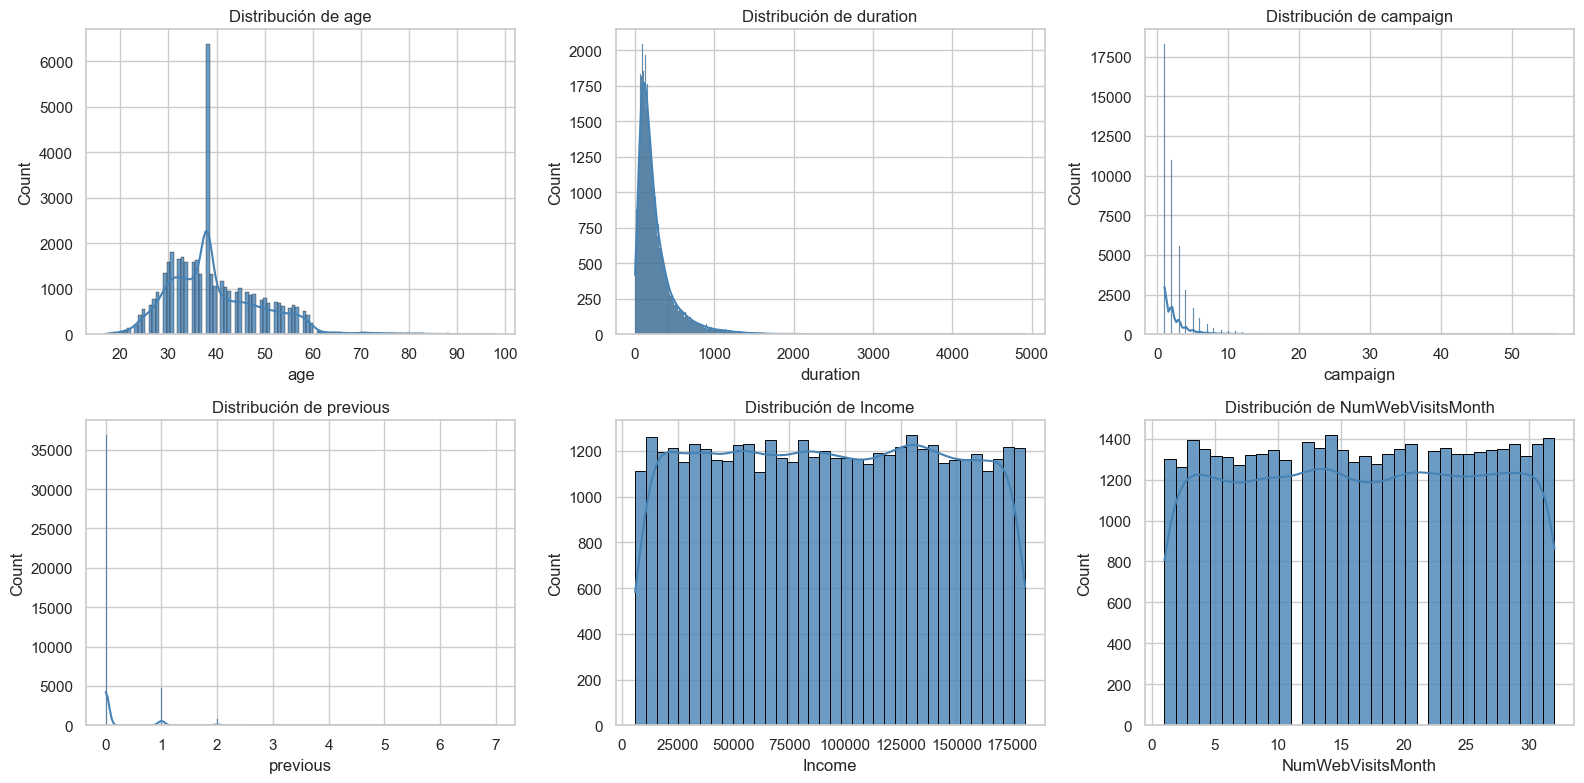

In [29]:
variables_numericas_interes = ["age", "duration", "campaign", "previous", "Income", "NumWebVisitsMonth"]

fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()

for ax, col in zip(axes, variables_numericas_interes):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()


In [30]:
# Realizamos analisis de las variables_numéricas_interes
df[variables_numericas_interes].describe().T


,count,mean,std,min,25%,50%,75%,max
age,42752.0,39.745018,9.822489,17.0,33.0,38.0,46.0,98.0
duration,42752.0,257.766186,258.778698,0.0,102.0,179.0,319.0,4918.0
campaign,42752.0,2.566383,2.770606,1.0,1.0,2.0,3.0,56.0
previous,42752.0,0.174237,0.497828,0.0,0.0,0.0,0.0,7.0
Income,42752.0,93225.591504,50495.796689,5841.0,49587.5,93016.0,136732.0,180802.0
NumWebVisitsMonth,42752.0,16.590007,9.239466,1.0,9.0,17.0,25.0,32.0


**Interpretación:**
- **`age`(edad del cliente)**: distribución aproximadamente simétrica, centrada entre 30 y 45 años, con una cola hacia edades más altas (clientes jubilados).
- **`duration`(duracion en segundos de ultima interacción)**: fuertemente sesgada a la derecha (la mayoría de llamadas son cortas, pocas muy largas). <br> La media (≈258 s) está muy por encima de la mediana, típico de esta variable.
- **`campaign`(numero contactos en campaña)**: la mayoría de clientes se contactan 1-3 veces en la campaña; pocos casos con muchos contactos.
- **`previous`(numero contactos previo a campaña)**: variable muy concentrada en 0 (la mayoría de clientes nunca fue contactado antes de esta campaña), como ya vimos en la Fase 2.
- **`Income`(ingreso anual del cliente)**: distribución bastante uniforme entre ~6.000 y ~181.000, sin un patrón de sesgo marcado — es coherente con que estos datos demográficos son independientes de la campaña.
- **`NumWebVisitsMonth`(Visitas cliente a Web)**: distribución razonablemente uniforme en el rango de visitas mensuales al sitio web.


Indicadores económicos (contexto macro de cada contacto)

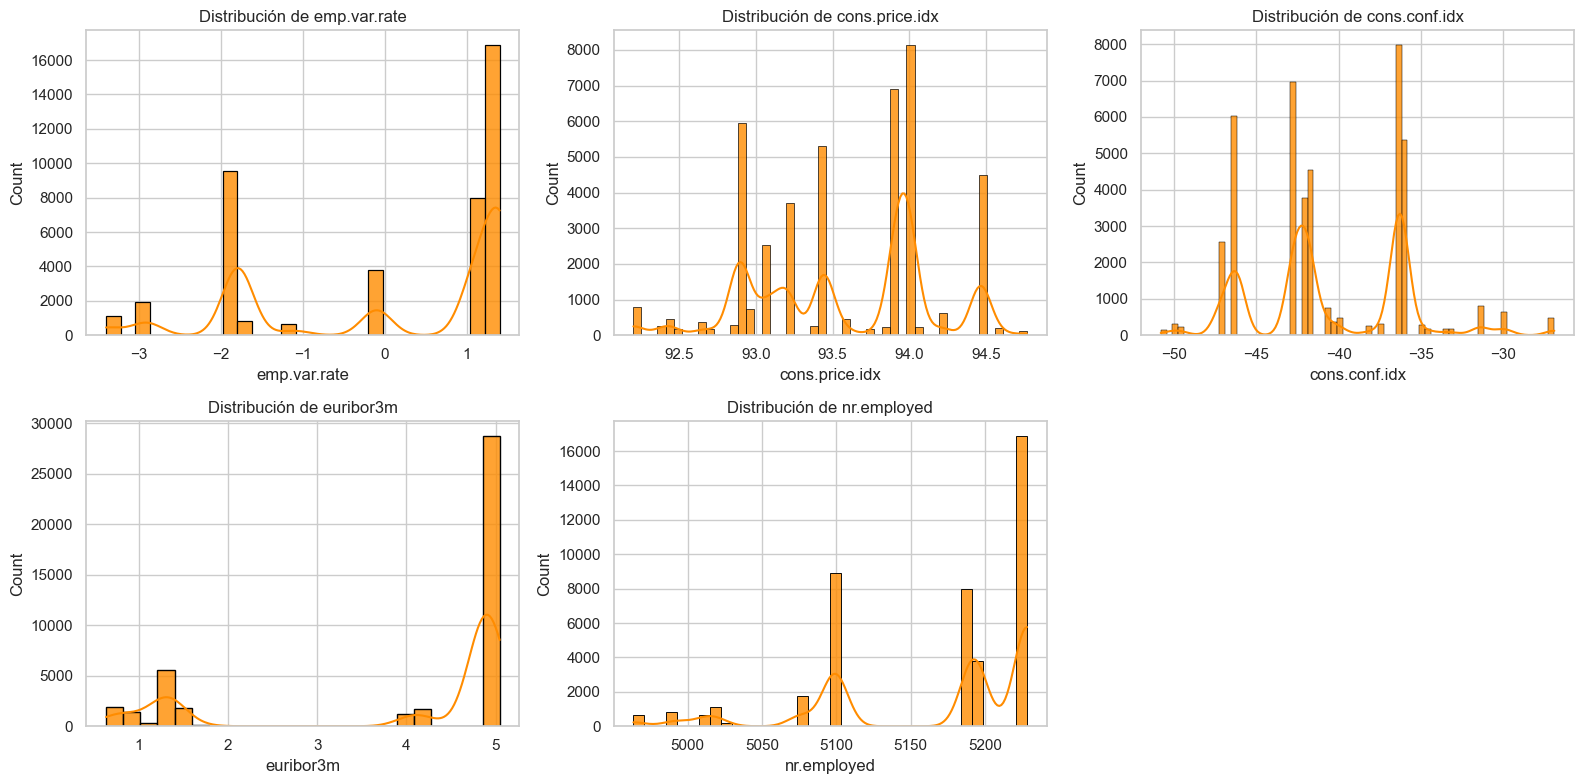

In [32]:
variables_macro = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()

for ax, col in zip(axes, variables_macro):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="darkorange", edgecolor="black", alpha=0.8)
    ax.set_title(f"Distribución de {col}")

axes[-1].axis("off") # oculatamos ultimo subgrafico
plt.tight_layout()
plt.show()


**Interpretación:** estas 5 variables no son **indicadores macroeconómicos** vigentes en el momento del contacto (tasa de variación del empleo, IPC, confianza del consumidor, euríbor y número de empleados). Sus distribuciones muestran varios "grupos" de valores concentrados, lo cual es coherente con que estos indicadores cambian poco a lo largo de periodos de varios meses (muchos contactos comparten el mismo valor macroeconómico).


#### 6️⃣ Análisis bivariante — Relación con la variable `y`

En lugar de usar `countplot(hue="y")` (que muestra cantidades absolutas y dificulta comparar categorías con tamaños distintos), calculamos la **tasa de suscripción (%) por categoría** con `groupby` valorando las suscripciones "yes" conprandoda con la profesión y la representamos con `barplot`. Esto responde directamente a la pregunta de negocio: *¿qué perfiles de cliente suscriben más según su profesión?*


6.1. Tasa de suscripción por profesión

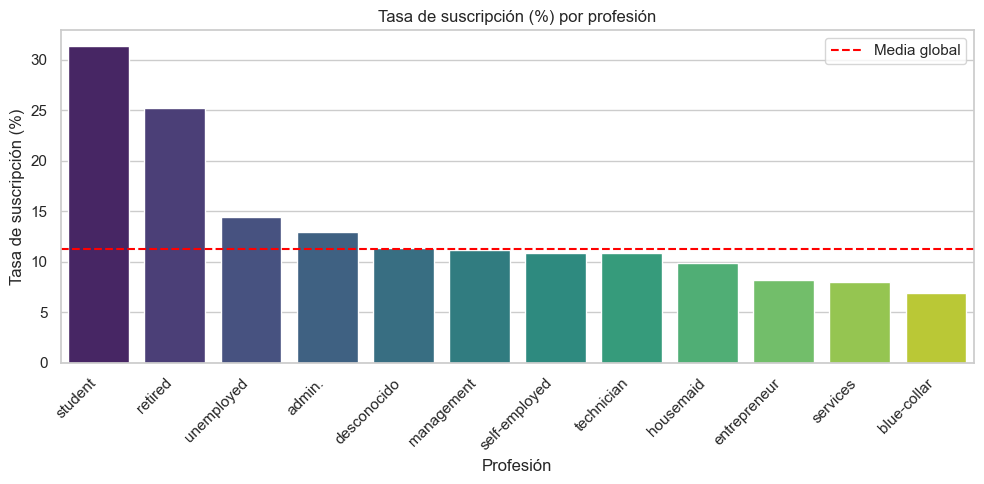

In [33]:
tasa_por_job = (
    (df["y"] == "yes")
    .groupby(df["job"])
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10,5))
sns.barplot(x=tasa_por_job.index, y=tasa_por_job.values, hue=tasa_por_job.index, palette="viridis", legend=False)
plt.axhline(y=df["y"].value_counts(normalize=True)["yes"]*100, color="red", linestyle="--", label="Media global")
plt.title("Tasa de suscripción (%) por profesión")
plt.xlabel("Profesión")
plt.ylabel("Tasa de suscripción (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Vemos los resultados
tasa_por_job = (
    (df["y"] == "yes")
    .groupby(df["job"])
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(tasa_por_job.round(2))

job
student          31.36
retired          25.25
unemployed       14.45
admin.           12.98
desconocido      11.34
management       11.13
self-employed    10.86
technician       10.84
housemaid         9.94
entrepreneur      8.22
services          8.05
blue-collar       6.89
Name: y, dtype: float64


**Interpretación:** 
- `student (estudiantes)` (≈31 %) y `retired (jubilados)` (≈25 %) son, por amplio margen, los perfiles con mayor tasa de suscripción — muy por encima de la media global (~11 %). 
- En el extremo opuesto, `blue-collar (sector obrero)` y `services (sector servicios)` convierten peor (~7-8 %). 

Esto sugiere que las campañas podrían priorizar estudiantes y jubilados.


6.2. Tasa de suscripción por método de contacto, resultado previo y contacto previo

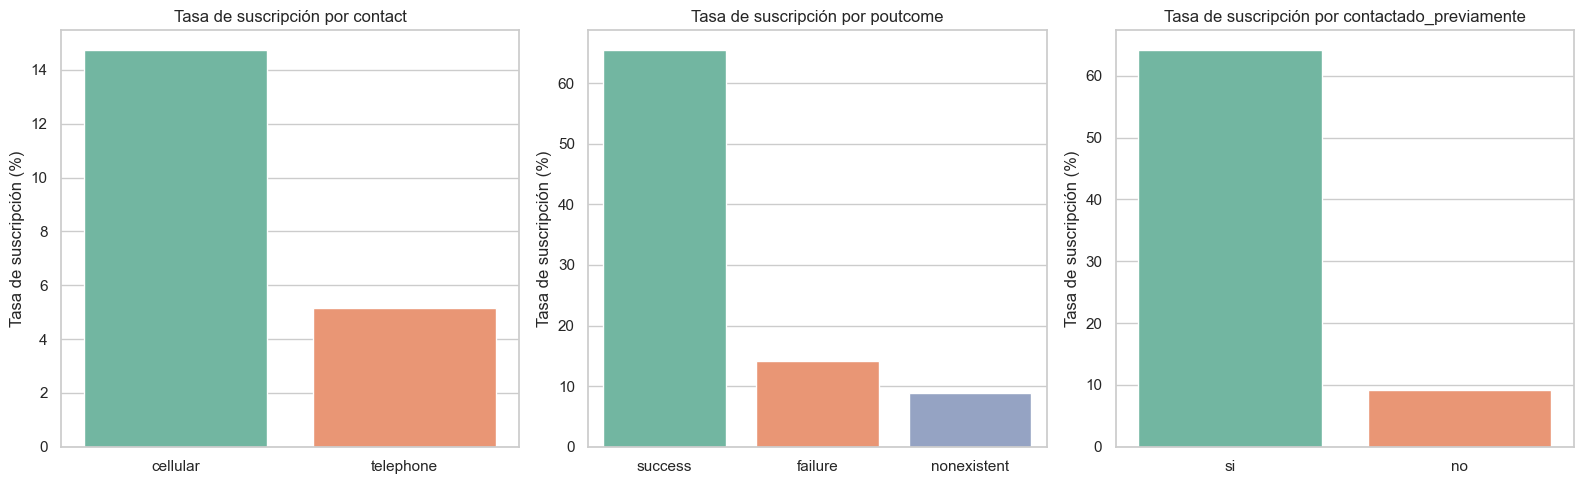

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, col in zip(axes, ["contact", "poutcome", "contactado_previamente"]):

    tasa = (
        (df["y"] == "yes")
        .groupby(df[col])
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    sns.barplot(
        x=tasa.index,
        y=tasa.values,
        hue=tasa.index,
        palette="Set2",
        legend=False,
        ax=ax
    )

    ax.set_title(f"Tasa de suscripción por {col}")
    ax.set_ylabel("Tasa de suscripción (%)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [38]:
# Vemos los resultados
for col in ["contact", "poutcome", "contactado_previamente"]:

    tasa = (
        (df["y"] == "yes")
        .groupby(df[col])
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(f"\nTasa de suscripción por {col}:")
    print(tasa.round(2))


Tasa de suscripción por contact:
contact
cellular     14.73
telephone     5.15
Name: y, dtype: float64

Tasa de suscripción por poutcome:
poutcome
success        65.43
failure        14.20
nonexistent     8.80
Name: y, dtype: float64

Tasa de suscripción por contactado_previamente:
contactado_previamente
si    64.11
no     9.23
Name: y, dtype: float64


**Interpretación — aqui debemos destacar el cliente contactado_previamente:**
- **`contact`**: contactar por `cellular` (≈14,7 %) convierte más del doble que por `telephone` (≈5,2 %).
- **`poutcome`**: si la campaña anterior tuvo éxito (`success`), la tasa de suscripción en esta campaña se dispara a **≈65 %**, frente al ≈8,8 % de quienes no tenían campaña previa y al ≈14,2 % de quienes fallaron antes.
- **`contactado_previamente`**: los clientes que ya habían sido contactados antes convierten al **≈64 %**, frente al **≈9,2 %** de los clientes nuevos.

**Conclusión de negocio:** el historial de contacto previo (haber sido cliente de una campaña anterior, especialmente exitosa) es, con diferencia, la señal más fuerte de que un cliente volverá a suscribir.


6.3. Variables numéricas vs variable objetivo "y" usaremos boxplot

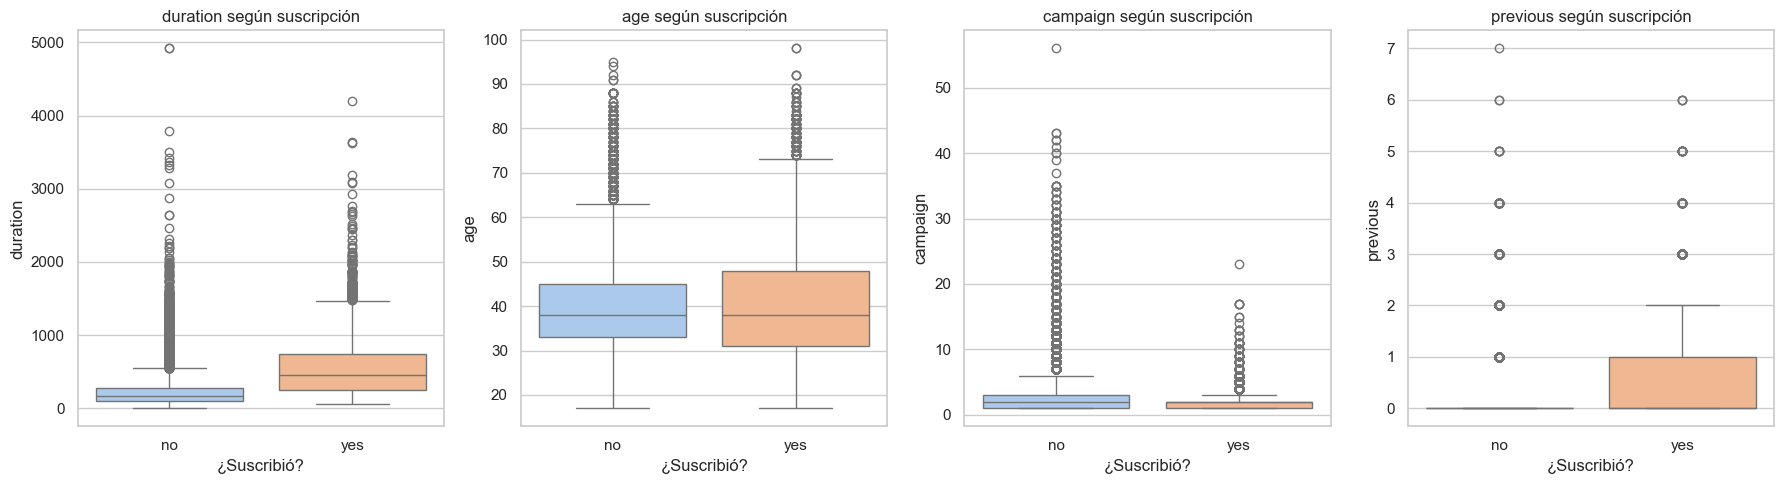

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(18,5))

for ax, col in zip(axes, ["duration", "age", "campaign", "previous"]):
    sns.boxplot(data=df, x="y", y=col, hue="y", palette="pastel", legend=False, ax=ax)
    ax.set_title(f"{col} según suscripción")
    ax.set_xlabel("¿Suscribió?")

plt.tight_layout()
plt.show()


In [42]:
df.groupby("y")[["duration", "age", "campaign", "previous"]].describe().T


y                         no          yes
duration count  37941.000000  4811.000000
         mean     220.386205   552.556017
         std      207.120800   398.593598
         min        0.000000    63.000000
         25%       95.000000   253.000000
         50%      163.000000   449.000000
         75%      278.000000   741.000000
         max     4918.000000  4199.000000
age      count  37941.000000  4811.000000
         mean      39.641391    40.562253
         std        9.332663    13.029074
         min       17.000000    17.000000
         25%       33.000000    31.000000
         50%       38.000000    38.000000
         75%       45.000000    48.000000
         max       95.000000    98.000000
campaign count  37941.000000  4811.000000
         mean       2.631797     2.050509
         std        2.874708     1.656006
         min        1.000000     1.000000
         25%        1.000000     1.000000
         50%        2.000000     2.000000
         75%        3.000000     2.000000
         max       56.000000    23.000000
previous count  37941.000000  4811.000000
         mean       0.132943     0.499896
         std        0.409734     0.871201
         min        0.000000     0.000000
         25%        0.000000     0.000000
         50%        0.000000     0.000000
         75%        0.000000     1.000000
         max        7.000000     6.000000

**Interpretación:**
- **`duration`**: diferencia muy marcada. La mediana de duración de llamada en clientes que **sí** suscriben es de ≈449 segundos, frente a ≈163 segundos en los que no. Cuanto más larga la conversación, mayor probabilidad de conversión (lógico: hay más interés/negociación real).
- **`age`**: las medianas son casi idénticas (38 años en ambos grupos), aunque el grupo que sí suscribe tiene mayor dispersión (clientes jóvenes y mayores están algo sobrerrepresentados, coherente con el hallazgo de `student`/`retired`).
- **`campaign`**: sin diferencias relevantes entre ambos grupos.
- **`previous`**: los que suscriben tienden a tener más contactos previos, coherente con el hallazgo de `contactado_previamente` y `poutcome`.


### 7️⃣ Relación entre variables numéricas

7.1. Scatterplot: edad vs duración de la llamada, coloreado por suscripción


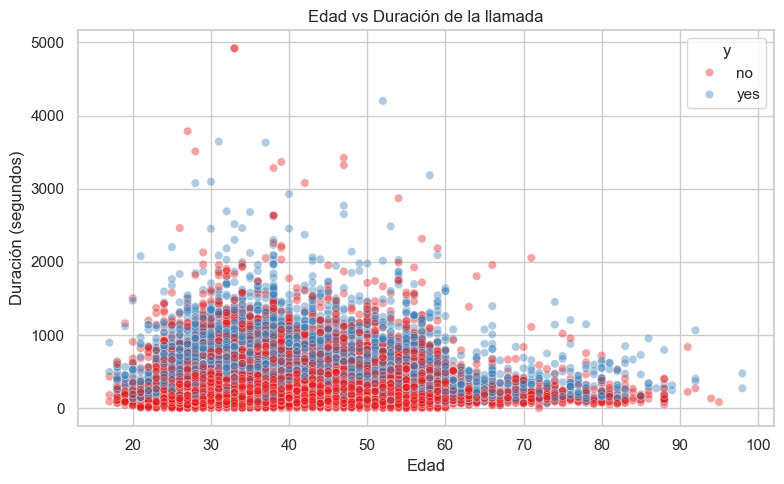

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="duration", hue="y", alpha=0.4, palette="Set1")
plt.title("Edad vs Duración de la llamada")
plt.xlabel("Edad")
plt.ylabel("Duración (segundos)")
plt.tight_layout()
plt.show()


In [ ]:
# Verificamos si existe correlacion entre age y duration
df[["age", "duration"]].corr()

,age,duration
age,1.000000,0.000214
duration,0.000214,1.000000


**Interpretación:** no se observa una relación lineal clara entre edad y duración. Sin embargo, se aprecia cómo los puntos (`yes`) se concentran más en la parte alta de duración, confirmando visualmente lo que vimos en el boxplot: la duración de la llamada es un mejor predictor de conversión que la edad.


7.2. Heatmap de correlaciones (variables numéricas + variable objetivo)

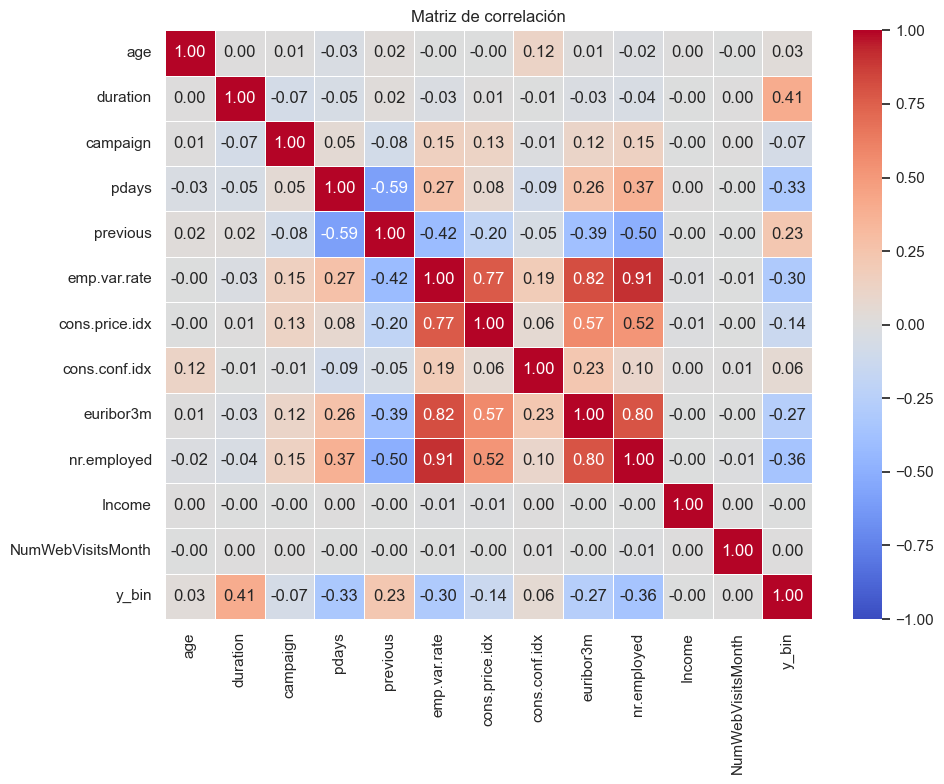

In [46]:
# Codificamos la variable "y" como 0/1 para poder incluirla en la matriz de correlación
df["y_bin"] = (df["y"] == "yes").astype(int)

columnas_corr = ["age", "duration", "campaign", "pdays", "previous",
                  "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
                  "Income", "NumWebVisitsMonth", "y_bin"]

corr = df[columnas_corr].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, linecolor="white", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


In [47]:
corr["y_bin"].sort_values(ascending=False)


y_bin                1.000000
duration             0.405651
previous             0.232944
cons.conf.idx        0.057121
age                  0.029627
NumWebVisitsMonth    0.000020
Income              -0.003984
campaign            -0.066304
cons.price.idx      -0.135270
euribor3m           -0.265106
emp.var.rate        -0.298201
pdays               -0.327359
nr.employed         -0.355707
Name: y_bin, dtype: float64

**Interpretación de las correlaciones con la variable objetivo (`y_bin`):**
- **`duration`** (+0,41) → la correlación más fuerte de todo el dataset. Confirma que la duración de la llamada es el mejor predictor numérico individual de conversión.
- **`previous`** (+0,23) → haber sido contactado antes se asocia positivamente con la conversión, en línea con el análisis bivariante categórico.
- **`nr.employed`** (-0,36), **`pdays`** (-0,33), **`emp.var.rate`** (-0,30), **`euribor3m`** (-0,27) → correlaciones negativas moderadas. Tiene sentido: estos indicadores suelen subir en épocas de expansión económica, donde los clientes tienen menos incentivo a mover su dinero a depósitos a plazo, mientras que en el caso de `pdays` un valor bajo (cliente contactado recientemente) se asocia a mayor conversión, de ahí el signo negativo (recordemos que 999 = "nunca contactado").
- **`Income`** (≈0,00) y **`NumWebVisitsMonth`** (≈0,00) → prácticamente sin relación lineal con la conversión. Los datos demográficos del Excel no parecen influir en la decisión de suscripción tanto como el propio proceso de contacto de la campaña.

**Además**, se observan correlaciones muy altas entre los propios indicadores macroeconómicos (`emp.var.rate`, `euribor3m`, `nr.employed`), lo cual es esperable porque son medidas relacionadas entre sí del mismo ciclo económico.


### 8️⃣ Evolución temporal

Analizamos cómo varía la tasa de suscripción mes a mes a lo largo de los 5 años que cubre el dataset (`date`).


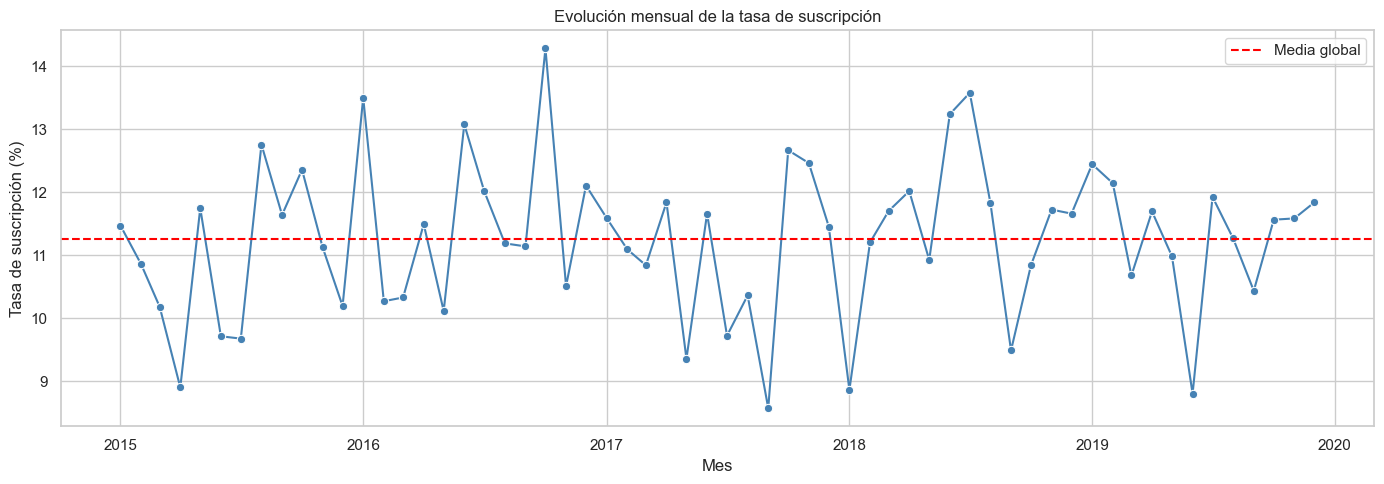

In [48]:
df["mes"] = df["date"].dt.to_period("M").astype(str)

tasa_mensual = df.groupby("mes")["y_bin"].mean() * 100
tasa_mensual.index = pd.to_datetime(tasa_mensual.index)

plt.figure(figsize=(14,5))
sns.lineplot(x=tasa_mensual.index, y=tasa_mensual.values, marker="o", color="steelblue")
plt.axhline(y=df["y_bin"].mean()*100, color="red", linestyle="--", label="Media global")
plt.title("Evolución mensual de la tasa de suscripción")
plt.xlabel("Mes")
plt.ylabel("Tasa de suscripción (%)")
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
print("Tasa mensual - estadísticos:")
print(tasa_mensual.describe())


Tasa mensual - estadísticos:
count    60.000000
mean     11.246566
std       1.222164
min       8.571429
25%      10.418775
50%      11.464974
75%      11.861823
max      14.285714
Name: y_bin, dtype: float64


**Interpretación:** la tasa de suscripción mensual oscila entre aproximadamente el **8,6 %** y el **14,3 %**, sin una tendencia creciente ni decreciente clara a lo largo de los 5 años — se mueve de forma bastante estable alrededor de la media global (~11 %). No se observa un patrón estacional evidente ni una mejora/deterioro sostenido de las campañas en el tiempo.


Volumen de contactos por mes (para contextualizar la evolución anterior)

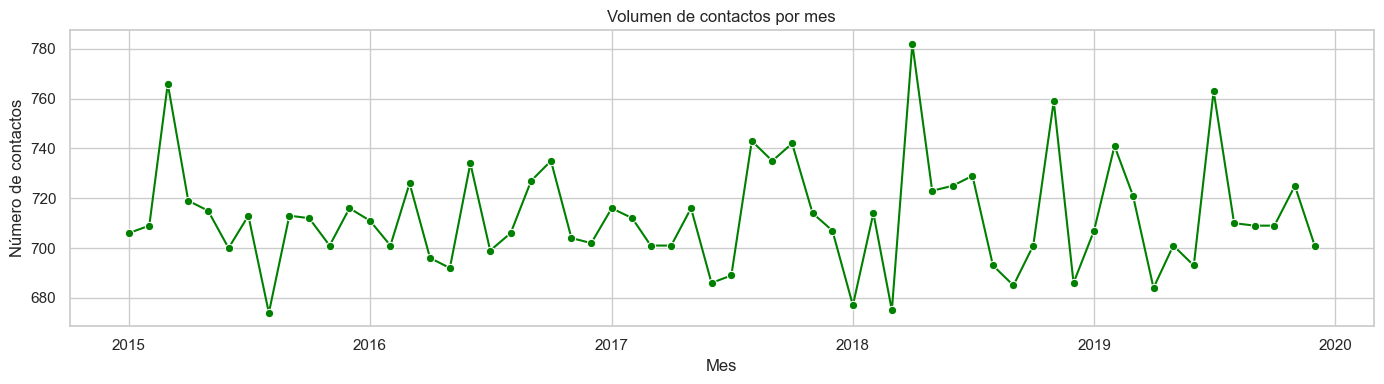

In [50]:
volumen_mensual = df.groupby("mes").size()
volumen_mensual.index = pd.to_datetime(volumen_mensual.index)

plt.figure(figsize=(14,4))
sns.lineplot(x=volumen_mensual.index, y=volumen_mensual.values, marker="o", color="green")
plt.title("Volumen de contactos por mes")
plt.xlabel("Mes")
plt.ylabel("Número de contactos")
plt.tight_layout()
plt.show()


**Interpretación:** el volumen de contactos mensuales es razonablemente constante durante todo el periodo, lo que da robustez a la comparación de tasas de conversión mes a mes (no hay meses con muestras pequeñas que puedan distorsionar la tasa).


### 9️⃣ Preguntas de negocio adicionales

Cerramos el EDA respondiendo a algunas preguntas concretas de negocio, combinando `groupby()`, `sort_values()` y filtrado con Pandas.


¿Qué combinación profesión + método de contacto convierte mejor?

In [51]:
tasa_job_contact = (
    df.groupby(["job", "contact"])["y_bin"]
    .agg(tasa_suscripcion="mean", n_clientes="count")
)
tasa_job_contact["tasa_suscripcion"] = (tasa_job_contact["tasa_suscripcion"] * 100).round(2)

# Filtramos combinaciones con un volumen mínimo para que la tasa sea representativa
tasa_job_contact[tasa_job_contact["n_clientes"] >= 100].sort_values("tasa_suscripcion", ascending=False).head(10)


,,tasa_suscripcion,n_clientes
job,contact,,
student,cellular,36.38,690
retired,cellular,31.46,1281
unemployed,cellular,20.00,655
admin.,cellular,16.25,7407
desconocido,cellular,15.73,178
self-employed,cellular,15.27,930
student,telephone,14.56,206
management,cellular,14.18,1989
technician,cellular,13.44,4821


¿Cómo varía la duración media de la llamada según si el cliente suscribe o no, por profesión?

In [52]:
df.groupby(["job", "y"])["duration"].mean().round(1)


job            y  
admin.         no     214.1
               yes    519.2
blue-collar    no     229.7
               yes    729.1
desconocido    no     205.4
               yes    525.0
entrepreneur   no     224.6
               yes    666.5
housemaid      no     218.3
               yes    537.5
management     no     220.3
               yes    536.9
retired        no     222.4
               yes    419.6
self-employed  no     221.6
               yes    608.1
services       no     224.7
               yes    642.9
student        no     225.9
               yes    400.1
technician     no     214.0
               yes    552.1
unemployed     no     212.4
               yes    472.2
Name: duration, dtype: float64

¿Qué nivel educativo tiene mayor ingreso medio (`Income`)?

In [53]:
df.groupby("education")["Income"].mean().round(0).sort_values(ascending=False)


education
high.school            94091.0
professional.course    93609.0
basic.9y               93575.0
desconocido            93134.0
university.degree      92774.0
basic.4y               92252.0
basic.6y               92172.0
illiterate             80480.0
Name: Income, dtype: float64

Top 10 meses con mayor tasa de suscripción

In [54]:
tasa_mensual.sort_values(ascending=False).head(10)


mes
2016-10-01    14.285714
2018-07-01    13.580247
2016-01-01    13.502110
2018-06-01    13.241379
2016-06-01    13.079019
2015-08-01    12.759644
2017-10-01    12.668464
2017-11-01    12.464986
2019-01-01    12.446959
2015-10-01    12.359551
Name: y_bin, dtype: float64

**Insights destacados:**
- Los estudiantes y jubilados contactados por `cellular` presentan las tasas de conversión más altas de todo el dataset, muy por encima del resto de combinaciones.
- La duración media de la llamada es sistemáticamente mayor en el grupo que suscribe, independientemente de la profesión — es un patrón consistente y no explicado por un único segmento.
- El nivel educativo no muestra una relación fuerte y consistente con el ingreso en estos datos (los ingresos parecen generados de forma bastante homogénea, recordemos que provienen de un archivo demográfico independiente de la campaña).
- No hay un mes o periodo concreto que destaque de forma aislada; los mejores meses superan la media global en 2-3 puntos porcentuales, una variación moderada y esperable por el tamaño de muestra mensual.


### Resumen de la Fase 3

**Principales hallazgos del EDA:**

1. **Dataset desbalanceado**: solo el 11,25 % de los clientes contactados suscribió el depósito.
2. **La duración de la llamada es el predictor individual más fuerte** de conversión (correlación +0,41 con la variable objetivo); las llamadas de clientes que suscriben duran, de mediana, casi el triple que las que no.
3. **El historial de contacto previo es la señal más potente**: los clientes ya contactados antes (y especialmente aquellos cuya campaña anterior tuvo éxito) convierten a tasas de 60-65 %, muy por encima del ~9-11 % del resto.
4. **El perfil demográfico importa**: `student` y `retired` son, con diferencia, las profesiones con mayor tasa de conversión (25-31 %), frente al 7-9 % de perfiles como `blue-collar` o `services`.
5. **El canal de contacto también influye**: `cellular` convierte más del doble que `telephone`.
6. **Los indicadores macroeconómicos** muestran correlaciones moderadas y coherentes con el ciclo económico, pero **la información demográfica del Excel (`Income`, `NumWebVisitsMonth`) apenas se relaciona con la conversión**.
7. **No se observa una tendencia temporal clara** a lo largo de los 5 años del dataset; la tasa de suscripción se mantiene relativamente estable mes a mes.

Estos hallazgos, junto con las tablas y gráficos generados en este notebook, serán la base del **informe final del proyecto (Fase 4)**.
